## **SAVE A COPY OF THIS NOTEBOOK TO PUT ANSWERS INTO. SUBMIT A PDF THAT HAS THE WRITTEN ANSWERS WITH THIS COLAB**


# Section 1: Reading Assignment

(25 pts)






For our first homework assignment, we want you to perform the process of pre-preocessing data to use for training models. This is especially important in a multimodal setting, where you have several modalities that can be extracted from raw data.

Before we start directly processing data, let's think about a project objective or idea that you want to acheive with multimodal modeling/AI. This can range from anything, so be as creative as you want! Here are some questions to answer to help get you started:

1. What goal (or goals) do you want your model to do? An example would be predicting the genre of a movie, or analyzing sentiment from a video. We want you to think about and discuss what is the end goal of the project that you will end up implementing later in the course.


**Answer**:

<blockquote>

The goal of this project is to develop a multimodal machine learning model that predicts key physical properties of perovskite materials, such as band gap and formation energy, by jointly leveraging crystal structure data and automatically generated textual descriptions.

Perovskite materials have emerged as a transformative class of compounds due to their remarkable tunability, high charge-carrier mobility, and versatile structural chemistry, making them pivotal in applications ranging from solar cells and light-emitting diodes to sensors and catalysis. Accurately predicting their properties is essential for guiding the rational design of new perovskites with targeted functionalities. Material design in this context involves tailoring chemical composition and crystal structure to optimize performance for specific applications, enabling a shift from trial-and-error synthesis to a more predictive, application-driven approach. The integration of domain knowledge with modern ML methods for different data modalities accelerates the sreening, discovery, and design of high-performance, cost-effective, and sustainable perovskite-based technologies.

By combining geometric structure with semantic descriptions, this project aims to:

· Improve prediction accuracy

· Capture complementary information across modalities

· Enable more interpretable material predictions

· Lay the foundation for interactive AI systems capable of reasoning about materials as well as inverse design of perovskite materials

</blockquote>

2. List out any datasets that you can find that can help accomplish this. Explain why you think the data is relevant and in addition discuss any drawbacks of the dataset.

**Answer**:
<blockquote>

Dataset: Custom $ABO_3$ Perovskite Multimodal Dataset

Origin: Extracted from the Materials Project (MP) via the mp-api Python client.

Dataset Size: After filtering, 592 valid ABO3 perovskite samples (from an initial 1,485 candidates).

Train/Validation/Test Split: 468 / 63 / 61 samples.

Data Provided per Sample:

- Structure: Crystal structure files (.cif)

- Text: Automated textual descriptions generated with Robocrystallographer

Target Properties:

 - band_gap (mean 1.607 eV, std 1.712 eV, range 0-6.09 eV)
 - formation_energy_per_atom (mean -2.754 eV/atom, std 0.752 eV/atom).

Relevance:

This dataset is particularly suited for multimodal materials modeling because each entry combines both structural (CIF) and textual (Robocrystallographer descriptions) information alongside accurate DFT-calculated labels. $ABO_3$ perovskites are a highly relevant material class, central to applications such as photovoltaics, catalysis, and superconductivity, making property prediction scientifically valuable. The rigorous filtering of the dataset that enforces stoichiometry, common perovskite space groups (Pm-3m, Pnma, R-3c, I4/mcm, P4mm, R3c), and low energy above hull ($<$ 0.1 eV) — ensures consistent chemical quality and structural reliability.

Limitations:

 - Small dataset size — Only 592 samples, which may be insufficient for training some deep learning models, especially large text encoders, and can lead to overfitting.

 - Synthetic text modality — Texts are generated algorithmically rather than curated by experts, potentially omitting subtle structural nuances, and lacking insights and depth seen in scientific literature.

 - Limited chemical diversity — Focus on ABO3 perovskites restricts generalization to other material families like spinels or layered compounds.

</blockquote>

3. What modalities do you choose to use? Why? Are there other modalities that could possibly be obtained that you don't plan on using? If so, why?

**Answer**:
<blockquote>

For this project, we focus on two primary modalities:

1. Crystal Structure (CIF files): This modality provides the complete 3D geometry of each material, including lattice parameters, space group symmetry, atomic positions, and site occupancies. The crystal structure is the most fundamental determinant of electronic and thermodynamic properties, as bond lengths, coordination environments, and symmetry directly influence properties like band gap and formation energy. It can be converted into well-structured graphs for processing with Graph Neural Networks and other graph-based model architectures.

2. Text Descriptions (Robocrystallographer output): These algorithmically generated natural-language descriptions summarize coordination geometries, bond lengths, and structural motifs. It provides comprehensive and semantically informative descriptions of local environments of each atomic site in the crystal structure, complementing the low-level geometric information in the crystal graph, while also offering interpretability through directly-readable natural language.

Traditional materials prediction models typically rely on a single modality. Structure-based graph neural networks achieve descent predictive performance but often lack interpretability and struggle to capture richer information for further improvement, while text-based models depend heavily on literature and struggle with DFT-simulated and newly proposed candidate materials. Structural representations encode atomic relationships, while textual descriptions summarize chemically meaningful patterns such as coordination environments and distortions. Integrating these modalities allows the model to learn richer representations, potentially uncovering implicit features that are difficult to extract from structure alone.

Several potentially relevant modalities are not used for various reasons:

 - X-ray Diffraction (XRD) patterns: Though XRD patterns can be simulated from CIFs, they are a 1D projection of the 3D structure and largely redundant with the crystal graph. Encoding XRD would add unnecessary complexity without new information.

 - Electronic Density of States (DOS) or Band Structure plots: These are derived properties from DFT simulations, which are extremely time- and compute-costly run. The resulting simulated data is very dense and high-dimensional, requiring unrealistically high amount of effort and domain expertise to process.

 - Chemical composition and composition-derived descriptors: The descriptors derived from chemical compositios are simple to compute, but they discard structural information and are therefore less informative than the full crystal graph.

 - Rendered images of crystal structures: As most of the materials in the dataset are not experimentally synthesized, visual representations can only be acquired through simple rule-based simluation, thus the resulting images do not add meaningful information beyond what is already encoded in the crystal graph.

</blockquote>

4. What difficulties did you encounter in obtaining the data?

**Answer**:
<blockquote>

Obtaining a high-quality $ABO_3$ perovskite dataset posed several challenges, reflecting both the computational and chemical complexities of assembling a clean, multimodal perovskite dataset suitable for ML modeling.

- Querying for Raw CIF Files: Obtaining the raw files from the Materials Project database required multiple carefully designed stages to isolate true perovskites from the broader set of ternary oxides. Furthermore, filtering of the perovskite candidates based on stability and self-consistency is essential to constructing a high-quality dataset. Initial API-level filters reduced the candidate pool, but rigorous checking for exact stoichiometry and valid perovskite-associated space groups (Pm-3m, Pnma, R-3c, I4/mcm, P4mm, R3c) were necessary to ensure chemical consistency, ultimately reducing 1,485 candidates to 592 samples.

- Generating Textual Descriptions with Robocrystallographer: The generation proess itself turned out to be nontrivial. About 16.7% of structures failed due to complex disorder, partial occupancies, or unusual bonding, creating missing data for the text modality. Additionally, running Robocrystallographer in its full-capacity mode was extremely slow and prone to disruptions, so we had to adopt a faster mode that skipped mineral prototype matching, trading descriptive detail for stability and speed.

- Limited Data Availability: Despite the Materials Project containing over 150,000 inorganic compounds, the strict $ABO_3$ perovskite filters yielded only ~600 samples, limiting the potential for effectively applying some deep learning methods.

- Environment and Dependency Management: Robocrystallographer relies on openbabel, requiring a dedicated conda environment (Python 3.11) separate from standard ML setups. Coordinating dependencies among different libraries required to process cif files and generate text, including pymatgen, mp-api, and robocrystallographer required careful configuration to avoid conflicts.

</blockquote>


5. Recall the [six core challenges of multimodal learning](https://arxiv.org/pdf/2209.03430). How do you plan on addressing them in your dataset or anticipate each of them impacting the way you design your dataset?

**Answer**:
<blockquote>

We plan to address the six core challenges of multimodal learning as follows:

1. Representation: The crystal structure and text modalities are fundamentally different ways of representing material information, namely the structred 3D graphs and unstructured natural language. We encode each modality separately using specialized encoders: a Graph Neural Network (e.g. CGCNN, ALIGNN, etc.) for crystal structures and a pretrained language model (e.g. MatBERT, SciBERT, etc.) for text. Each encoder produces a fixed-length vector, which is then fused into holistic representations for the materials of interest. Different integration techniques (e.g. concatenation, late fusion, gated fusion, bilinear pooling) may be explored to preserve modality-specific strengths while enabling synergetic potential for downstream tasks.

2. Alignment: At the sample level, alignment is straightforward since each material has one CIF and one text description. In the context of property prediction, fine-grained alignment between specific text phrases and graph substructures may be achieved by incorporating cross-attention mechanisms during fusion, allowing the model to learn associate specific NL structural descriptions and entities within crystal graphs (e.g. “octahedral coordination” in text = a 6-coordinated atom node). Global alignment of the two modalities in a shared latent space doesn't directly benefit our main task of property predictio and can be particularly challenging, but may be explored preliminarily in the context of inverse design tasks (e.g. NL requirement of materials -> NL descriptions of structural features -> crystal structure).

3. Reasoning: Predicting properties like band gap requires combining information from both modalities. In the property prediction task, the fusion module acts as a reasoning module, integrating structural features (bond lengths, tilts, symmetry) with textual descriptors (coordination patterns, distortion). attention mechanisms may be incorporated into the fusion module to better explain how different parts of information within each modality contributes to the final prediction results. For inverse-design tasks, reasoning extends to predicting how compositional changes will shift the target properties, with the possiblity of generating NL explanations as agentic .

4. Generation: While our main task is regression, generative aspects are relevant downstream. Robocrystallographer already provides text generation from structure, and future work involves fine-tuning a language model to complete or generate text conditioned on structural features. We would further consider exploring the use of LLMs to generate chemistry knowledge summary (e.g. on structure-property relations, specific properties, etc.) to better inform property prediction. Inverse design, which proposes new elemental substitutions, also constitutes discrete “generation” of candidate structures.

5. Transference: Some samples (16.7%) lack text descriptions, so the model must transfer knowledge across modalities. Pretrained encoders such as SciBERT provide transfer learning from large datasets. During joint training on complete samples, the structure encoder can implicitly capture information present in text, enabling reasonable predictions for structure-only samples. We also design ablation studies (structure-only, text-only, fusion) to quantify the effects of cross-modal transfer.

6. Quantification: Since text is algorithmically derived from structure, it may be redundant. To measure the roles of different data modalities, we compare unimodal versus multimodal models, analyze attention weights to identify predictive features, perform error analysis across material types, and potentially compute mutual information between embeddings. This allows us to quantify how much unique information the text modality contributes beyond the structure.

</blockquote>

# Section 2
(20 pts)

We have provided a skeleton for you to start coding with, which contains an example of extracting frames of a video as images. Feel free to use this code as a starting point, but you are free to and encouraged to add more! The goal of this assignment (and what you will be graded on), is to extract a set of modalities from the dataset of your choice that is rich (in the sense that it would make sense to use/has valuable information) and contains unique information from other modalities.

**We strongly encourage that you take a good amount of time exploring and choosing the dataset you want to go with. The dataset/domain you decide to go with and the modalities you choose will be used for the rest of the HWs in this class. Create your dataset with this in mind!**

**You will submit a copy of this notebook with the code alongside your writeup. In your writeup, discuss the following:**

What difficulties did you encounter in extracting the modalities?


<blockquote>

**Answer**

The difficulties encountered in extracting modalities include:

**Crystal Structures (CIF)**:

 - Querying for Raw CIF Files: Collecting the raw structural data from the Materials Project involved a multi-step screening procedure to distinguish reasonable perovskite simulations from the larger pool of ternary oxides. Beyond basic retrieval, additional filtering based on thermodynamic stability and structural consistency was critical to ensure dataset reliability. On top of preliminary API constraints, additional steps were necessary to enforce exact $ABO_3$ stoichiometry and restricting structures to established perovskite space groups (Pm-3m, Pnma, R-3c, I4/mcm, P4mm, R3c).


 **Text (Robocrystallographer)**:


- Environment and Dependency Management: Robocrystallographer necessitates creating a separate conda environment (Python 3.11) distinct from the typical machine learning project setup. Managing compatibility among the required packages for CIF processing and text generation (including pymatgen, mp-api, and robocrystallographer) demanded careful dependency resolution and environment configuration to prevent version conflicts and installation errors.

- Text Generation: Approximately 16.7% of the structures could not be processed successfully, typically due to issues including structural disorder, partial atomic occupancies, or atypical bonding environments, resulting in missing entries for the text modality. Moreover, operating Robocrystallographer in its full-feature mode was computationally intensive and susceptible to interruptions. To ensure reliable execution, we switched to a streamlined configuration that omits mineral prototype matching to ensure an acceptable execution speed and stability.

</blockquote>



## Querying and Filtering CIF Files

In [ ]:
!pip install -q mp-api pymatgen pandas pyarrow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 2.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.4/119.4 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 59.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 308.8/308.8 kB 22.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.9/51.9 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 332.3/332.3 kB 23.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.1/118.1 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 962.5/962.5 kB 47.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.6/140.6 kB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.6/14.6 MB 83.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.4/127.4 kB 9.2 MB/s eta 0:00:00
   

In [ ]:
from __future__ import annotations

import argparse
import hashlib
import json
import os
from datetime import datetime
from dataclasses import dataclass
from pathlib import Path
import math
from typing import Dict, Iterable, List, Optional, Tuple

import pandas as pd
from mp_api.client import MPRester
from pymatgen.core import Composition
from pymatgen.io.cif import CifWriter

DEFAULT_FIELDS = [
    "material_id",
    "formula_pretty",
    "elements",
    "nelements",
    "band_gap",
    "formation_energy_per_atom",
    "energy_above_hull",
    "is_metal",
    "symmetry",
    "structure",
]


@dataclass
class SiteElements:
    a_site: str
    b_site: str


def parse_args() -> argparse.Namespace:
    parser = argparse.ArgumentParser(
        description="Fetch and build ABO3 dataset from Materials Project."
    )
    parser.add_argument(
        "--api-key",
        type=str,
        default=os.getenv("MP_API_KEY", "").strip(),
        help="Materials Project API key. If omitted, use MP_API_KEY env var.",
    )
    parser.add_argument(
        "--output-root",
        type=Path,
        default=Path("data"),
        help="Output root directory.",
    )
    parser.add_argument(
        "--max-e-above-hull",
        type=float,
        default=0.10,
        help="Upper bound for energy_above_hull used in MP search.",
    )
    parser.add_argument(
        "--max-count",
        type=int,
        default=0,
        help="Optional cap on number of MP docs fetched (0 means no cap).",
    )
    parser.add_argument(
        "--strict-perovskite-spacegroups",
        action="store_true",
        help="If set, keep only common perovskite spacegroups.",
    )
    parser.add_argument(
        "--processed-version",
        type=str,
        default="multimodal_v1",
        help="Version folder name under data/processed/",
    )
    parser.add_argument(
        "--snapshot-tag",
        type=str,
        default="",
        help="Optional raw snapshot tag. Default uses current date YYYYMMDD.",
    )
    parser.add_argument(
        "--chunk-size",
        type=int,
        default=500,
        help="MP API chunk size for paginated fetching.",
    )
    parser.add_argument(
        "--disable-formula-abc3-prefilter",
        action="store_true",
        help="Disable formula='ABC3' prefilter (not recommended for speed).",
    )
    return parser.parse_args()


def composition_is_abo3(formula: str) -> Tuple[bool, Optional[SiteElements]]:
    """
    Check if reduced composition is exactly A1B1O3.
    """
    comp = Composition(formula)
    reduced: Dict[str, float] = comp.reduced_composition.get_el_amt_dict()
    if len(reduced) != 3 or "O" not in reduced:
        return False, None
    if abs(reduced["O"] - 3.0) > 1e-8:
        return False, None
    other = [(el, amt) for el, amt in reduced.items() if el != "O"]
    if len(other) != 2:
        return False, None
    if any(abs(amt - 1.0) > 1e-8 for _, amt in other):
        return False, None
    # A/B assignment here follows alphabetical order for determinism.
    sorted_other = sorted(other, key=lambda x: x[0])
    return True, SiteElements(a_site=sorted_other[0][0], b_site=sorted_other[1][0])


def is_perovskite_like_spacegroup(symbol: Optional[str]) -> bool:
    if not symbol:
        return False
    allowed = {
        "Pm-3m",  # cubic perovskite
        "Pnma",   # orthorhombic distorted perovskite
        "R-3c",   # rhombohedral perovskite
        "I4/mcm", # tetragonal tilted perovskite
        "P4mm",   # tetragonal ferroelectric perovskite
        "R3c",    # ferroelectric rhombohedral
    }
    return symbol in allowed


def safe_structure_dict(structure_obj) -> str:
    """
    Serialize structure to a compact JSON string for raw storage.
    """
    return json.dumps(structure_obj.as_dict(), separators=(",", ":"))


def bytes_to_human(n_bytes: int) -> str:
    units = ["B", "KB", "MB", "GB", "TB"]
    size = float(n_bytes)
    for u in units:
        if size < 1024.0 or u == units[-1]:
            return f"{size:.2f} {u}"
        size /= 1024.0
    return f"{n_bytes} B"


def dir_size_bytes(path: Path) -> int:
    if not path.exists():
        return 0
    total = 0
    for p in path.rglob("*"):
        if p.is_file():
            total += p.stat().st_size
    return total


def estimate_total_size(
    n_rows: int,
    raw_parquet_size: int,
    processed_parquet_size: int,
    cif_total_size: int,
) -> Dict[str, str]:
    if n_rows <= 0:
        return {"4000_rows": "N/A", "6000_rows": "N/A"}
    avg = (raw_parquet_size + processed_parquet_size + cif_total_size) / n_rows
    estimate_4k = int(avg * 4000)
    estimate_6k = int(avg * 6000)
    return {
        "4000_rows": bytes_to_human(estimate_4k),
        "6000_rows": bytes_to_human(estimate_6k),
    }


def truncate_iter(items: Iterable, max_count: int) -> List:
    if max_count <= 0:
        return list(items)
    result = []
    for idx, item in enumerate(items, start=1):
        result.append(item)
        if idx >= max_count:
            break
    return result


def build_split_map(material_ids: List[str], split_seed: int = 42) -> pd.DataFrame:
    """
    Deterministic random split map by material_id.
    80% train, 10% val, 10% test.
    """
    if not material_ids:
        return pd.DataFrame(columns=["material_id", "split"])
    s = pd.Series(sorted(material_ids))
    # stable hash-based assignment to avoid random hash seeds across runs
    def to_bucket(mid: str) -> float:
        digest = hashlib.sha256(f"{mid}|{split_seed}".encode("utf-8")).hexdigest()
        return (int(digest[:8], 16) % 1000) / 1000.0

    bucket = s.apply(to_bucket)
    split = bucket.map(
        lambda v: "train" if v < 0.8 else ("val" if v < 0.9 else "test")
    )
    return pd.DataFrame({"material_id": s, "split": split})


def build_mp_perovskite_dataset(
    api_key: str,
    output_root: Path = Path("data"),
    max_e_above_hull: float = 0.10,
    max_count: int = 0,
    strict_perovskite_spacegroups: bool = False,
    processed_version: str = "multimodal_v1",
    snapshot_tag: str = "",
    chunk_size: int = 500,
    disable_formula_abc3_prefilter: bool = False,
) -> None:
    """
    Build an ABO3 perovskite dataset from Materials Project.

    This function performs:
      1. MP query
      2. ABO3 stoichiometry filtering
      3. Optional perovskite spacegroup filtering
      4. CIF export
      5. Raw / interim / processed parquet writing
      6. Deterministic train/val/test splitting
      7. Metadata writing
      8. Storage size estimation
    """

    if not api_key:
        raise ValueError("Missing MP API key.")

    snapshot_tag = snapshot_tag.strip() or datetime.now().strftime("%Y%m%d")

    raw_dir = output_root / "raw" / f"mp_snapshot_{snapshot_tag}"
    interim_dir = output_root / "interim" / "filtered_abo3"
    processed_dir = output_root / "processed" / processed_version
    cif_dir = processed_dir / "cifs"

    for d in [raw_dir, interim_dir, processed_dir, cif_dir]:
        d.mkdir(parents=True, exist_ok=True)

    print("[1/4] Querying Materials Project...")

    formula_filter = None if disable_formula_abc3_prefilter else "ABC3"
    num_chunks = None
    if max_count > 0:
        num_chunks = max(1, math.ceil(max_count / chunk_size))

    with MPRester(api_key) as mpr:

        count_criteria = {
            "elements": "O",
            "nelements_min": 3,
            "nelements_max": 3,
            "energy_above_hull_min": 0,
            "energy_above_hull_max": max_e_above_hull,
        }
        if formula_filter:
            count_criteria["formula"] = formula_filter

        try:
            rough_count = mpr.materials.summary.count(count_criteria)
            print(f"Count estimate before fetch: {rough_count}")
        except Exception:
            rough_count = None

        docs_iter = mpr.materials.summary.search(
            elements=["O"],
            num_elements=(3, 3),
            formula=formula_filter,
            energy_above_hull=(0, max_e_above_hull),
            fields=DEFAULT_FIELDS,
            chunk_size=chunk_size,
            num_chunks=num_chunks,
        )

        docs = truncate_iter(docs_iter, max_count)

    print(f"Fetched docs: {len(docs)}")
    print("[2/4] Filtering ABO3 stoichiometry...")

    raw_rows = []
    processed_rows = []

    for d in docs:

        is_abo3, site_info = composition_is_abo3(d.formula_pretty)
        if not is_abo3 or site_info is None:
            continue

        sym_symbol = None
        sym_number = None
        crystal_system = None

        if getattr(d, "symmetry", None):
            sym_symbol = getattr(d.symmetry, "symbol", None)
            sym_number = getattr(d.symmetry, "number", None)
            crystal_system = getattr(d.symmetry, "crystal_system", None)
            if crystal_system is not None:
                crystal_system = str(crystal_system)

        if strict_perovskite_spacegroups and not is_perovskite_like_spacegroup(sym_symbol):
            continue

        mat_id = str(d.material_id)
        structure = d.structure

        cif_path = cif_dir / f"{mat_id}.cif"
        CifWriter(structure).write_file(str(cif_path))

        raw_rows.append({
            "material_id": mat_id,
            "formula_pretty": d.formula_pretty,
            "elements": [str(el) for el in d.elements],
            "nelements": d.nelements,
            "band_gap": d.band_gap,
            "formation_energy_per_atom": d.formation_energy_per_atom,
            "energy_above_hull": d.energy_above_hull,
            "is_metal": d.is_metal,
            "spacegroup_symbol": sym_symbol,
            "spacegroup_number": sym_number,
            "crystal_system": crystal_system,
            "structure_json": safe_structure_dict(structure),
        })

        processed_rows.append({
            "material_id": mat_id,
            "formula": d.formula_pretty,
            "a_site": site_info.a_site,
            "b_site": site_info.b_site,
            "is_abo3_stoich": True,
            "is_perovskite_like_sg": is_perovskite_like_spacegroup(sym_symbol),
            "spacegroup_symbol": sym_symbol,
            "cif_path": str(cif_path),
            "band_gap": d.band_gap,
            "formation_energy_per_atom": d.formation_energy_per_atom,
            "energy_above_hull": d.energy_above_hull,
            "is_metal": d.is_metal,
            "robocrys_text": "",
            "data_source": "materials_project",
            "pipeline_version": "v1",
        })

    print(f"ABO3 rows kept: {len(processed_rows)}")
    print("[3/4] Writing layered dataset files...")

    raw_df = pd.DataFrame(raw_rows)
    interim_df = pd.DataFrame(processed_rows)

    split_map_df = build_split_map(interim_df["material_id"].tolist())
    processed_df = interim_df.merge(split_map_df, on="material_id", how="left")

    raw_path = raw_dir / "mp_abo3_raw.parquet"
    interim_path = interim_dir / "perovskite_abo3.parquet"
    split_map_path = interim_dir / "split_map.parquet"
    processed_path = processed_dir / "dataset.parquet"
    meta_path = raw_dir / "query_meta.json"

    raw_df.to_parquet(raw_path, index=False)
    interim_df.to_parquet(interim_path, index=False)
    split_map_df.to_parquet(split_map_path, index=False)
    processed_df.to_parquet(processed_path, index=False)

    query_meta = {
        "snapshot_tag": snapshot_tag,
        "timestamp_local": datetime.now().isoformat(timespec="seconds"),
        "counts": {
            "fetched_docs": len(docs),
            "abo3_rows": len(interim_df),
            "final_rows": len(processed_df),
        },
        "query": {
            "formula": formula_filter,
            "energy_above_hull_range": [0, max_e_above_hull],
            "strict_perovskite_spacegroups": strict_perovskite_spacegroups,
            "max_count": max_count,
            "chunk_size": chunk_size,
            "num_chunks": num_chunks,
            "count_estimate": rough_count,
        },
    }

    meta_path.write_text(json.dumps(query_meta, indent=2), encoding="utf-8")

    print("[4/4] Estimating storage...")

    raw_size = raw_path.stat().st_size if raw_path.exists() else 0
    meta_size = meta_path.stat().st_size if meta_path.exists() else 0
    interim_size = interim_path.stat().st_size if interim_path.exists() else 0
    split_size = split_map_path.stat().st_size if split_map_path.exists() else 0
    processed_size = processed_path.stat().st_size if processed_path.exists() else 0
    cif_size = dir_size_bytes(cif_dir)

    total_size = raw_size + meta_size + interim_size + split_size + processed_size + cif_size

    estimates = estimate_total_size(
        n_rows=len(processed_df),
        raw_parquet_size=raw_size,
        processed_parquet_size=interim_size + split_size + processed_size + meta_size,
        cif_total_size=cif_size,
    )

    print("\n=== Storage Report ===")
    print(f"Rows: {len(processed_df)}")
    print(f"Total (current): {bytes_to_human(total_size)}")
    print(f"Estimated total for 4,000 rows: {estimates['4000_rows']}")
    print(f"Estimated total for 6,000 rows: {estimates['6000_rows']}")


In [ ]:
from pathlib import Path

build_mp_perovskite_dataset(
    api_key=Path("YD_mp_api_key.txt").read_text(encoding="utf-8").strip(),
    max_e_above_hull=0.1,
    strict_perovskite_spacegroups=True,
)


[1/4] Querying Materials Project...
Count estimate before fetch: 1485


Retrieving SummaryDoc documents:   0%|          | 0/1485 [00:00<?, ?it/s]

Fetched docs: 1485
[2/4] Filtering ABO3 stoichiometry...
ABO3 rows kept: 592
[3/4] Writing layered dataset files...
[4/4] Estimating storage...

=== Storage Report ===
Rows: 592
Total (current): 1.46 MB
Estimated total for 4,000 rows: 9.85 MB
Estimated total for 6,000 rows: 14.78 MB


## Text Generation

In [ ]:
!pip install -q pymatgen pandas robocrys

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 31.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 23.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.0/35.0 MB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 59.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 331.1/331.1 kB 16.9 MB/s eta 0:00:00


In [ ]:
from pathlib import Path
import warnings
import pandas as pd
from pymatgen.core import Structure
from robocrys import StructureCondenser, StructureDescriber

def should_skip(existing_text: object, overwrite: bool) -> bool:
    if overwrite:
        return False
    if isinstance(existing_text, str) and existing_text.strip():
        return True
    return False

def generate_robocrys_text(
    processed_dir: Path,
    write_text_files: bool = False,
    overwrite: bool = False,
    max_count: int = 0,
    conventional: bool = False,
    symmetry_equivalent: bool = False,
    symprec: float = 0.01,
    enable_mineral_match: bool = False,
    show_known_warnings: bool = False,
    progress_every: int = 50,
    failed_log_path: Path | None = None,
) -> None:
    """
    Generate Robocrystallographer text descriptions for all rows in a processed dataset.

    Updates `robocrys_text` column in-place, optionally writes per-material text files,
    and logs failed rows to CSV.
    """
    dataset_path = processed_dir / "dataset.parquet"
    texts_dir = processed_dir / "texts"
    failed_log_path = failed_log_path or processed_dir / "robocrys_failures.csv"

    if write_text_files:
        texts_dir.mkdir(parents=True, exist_ok=True)
    if not dataset_path.exists():
        raise FileNotFoundError(f"Dataset file not found: {dataset_path}")

    if not show_known_warnings:
        warnings.filterwarnings("ignore", message=r"No oxidation states specified on sites!.*")
        warnings.filterwarnings("ignore", message=r"CrystalNN: cannot locate an appropriate radius.*")

    df = pd.read_parquet(dataset_path)
    if "robocrys_text" not in df.columns:
        df["robocrys_text"] = ""

    condenser = StructureCondenser(
        use_conventional_cell=conventional,
        use_symmetry_equivalent_sites=symmetry_equivalent,
        symprec=symprec,
        mineral_matcher=None if enable_mineral_match else False,
    )
    describer = StructureDescriber(describe_mineral=enable_mineral_match)

    total = len(df)
    processed = 0
    skipped = 0
    failed = 0
    failed_rows: list[dict[str, str]] = []

    for idx, row in df.iterrows():
        if max_count > 0 and processed >= max_count:
            break

        if should_skip(row.get("robocrys_text", ""), overwrite):
            skipped += 1
            continue

        cif_path = Path(str(row["cif_path"]))
        if not cif_path.exists():
            failed += 1
            failed_rows.append(
                {
                    "material_id": str(row.get("material_id", "")),
                    "cif_path": str(cif_path),
                    "error": "cif_not_found",
                }
            )
            continue

        try:
            structure = Structure.from_file(cif_path)
            condensed = condenser.condense_structure(structure)
            text = describer.describe(condensed)
            df.at[idx, "robocrys_text"] = text
            if write_text_files:
                mat_id = str(row["material_id"])
                (texts_dir / f"{mat_id}.txt").write_text(text, encoding="utf-8")
            processed += 1
            if progress_every > 0 and processed % progress_every == 0:
                print(
                    f"[progress] generated={processed}, "
                    f"skipped={skipped}, failed={failed}"
                )
        except Exception:
            failed += 1
            failed_rows.append(
                {
                    "material_id": str(row.get("material_id", "")),
                    "cif_path": str(cif_path),
                    "error": "robocrys_generation_failed",
                }
            )

    df.to_parquet(dataset_path, index=False)
    if failed_rows:
        pd.DataFrame(failed_rows).to_csv(failed_log_path, index=False)

    print("=== robocrys generation report ===")
    print(f"rows_total: {total}")
    print(f"rows_generated: {processed}")
    print(f"rows_skipped_existing: {skipped}")
    print(f"rows_failed: {failed}")
    print(f"dataset_written: {dataset_path}")
    if failed_rows:
        print(f"failed_log_written: {failed_log_path}")
    if write_text_files:
        print(f"text_dir: {texts_dir}")

In [ ]:
generate_robocrys_text(
    processed_dir=Path("data/processed/multimodal_v1"),
    write_text_files=True,
    overwrite=False,
    progress_every=20,
)

[progress] generated=20, skipped=0, failed=0
[progress] generated=40, skipped=0, failed=0
[progress] generated=60, skipped=0, failed=0
[progress] generated=80, skipped=0, failed=0
[progress] generated=100, skipped=0, failed=0


/usr/local/lib/python3.12/dist-packages/robocrys/condense/molecule.py:127: RuntimeWarning: Molecule naming requires openbabel to be installed with Python bindings. Please get it at http://openbabel.org.
  warnings.warn(


[progress] generated=120, skipped=0, failed=0
[progress] generated=140, skipped=0, failed=0


/usr/local/lib/python3.12/dist-packages/robocrys/condense/molecule.py:127: RuntimeWarning: Molecule naming requires openbabel to be installed with Python bindings. Please get it at http://openbabel.org.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/robocrys/condense/molecule.py:127: RuntimeWarning: Molecule naming requires openbabel to be installed with Python bindings. Please get it at http://openbabel.org.
  warnings.warn(


[progress] generated=160, skipped=0, failed=0


...

[progress] generated=300, skipped=0, failed=0
[progress] generated=320, skipped=0, failed=0
[progress] generated=340, skipped=0, failed=0
[progress] generated=360, skipped=0, failed=0
[progress] generated=380, skipped=0, failed=0
[progress] generated=400, skipped=0, failed=0
[progress] generated=420, skipped=0, failed=0
[progress] generated=440, skipped=0, failed=0
[progress] generated=460, skipped=0, failed=0


/usr/local/lib/python3.12/dist-packages/robocrys/condense/molecule.py:127: RuntimeWarning: Molecule naming requires openbabel to be installed with Python bindings. Please get it at http://openbabel.org.
  warnings.warn(


[progress] generated=480, skipped=0, failed=0
[progress] generated=500, skipped=0, failed=0
[progress] generated=520, skipped=0, failed=0
[progress] generated=540, skipped=0, failed=0
[progress] generated=560, skipped=0, failed=0


/usr/local/lib/python3.12/dist-packages/pymatgen/core/structure.py:3109: UserWarning: Issues encountered while parsing CIF: 2 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  struct = parser.parse_structures(primitive=primitive)[0]


[progress] generated=580, skipped=0, failed=0
=== robocrys generation report ===
rows_total: 592
rows_generated: 592
rows_skipped_existing: 0
rows_failed: 0
dataset_written: data/processed/multimodal_v1/dataset.parquet
text_dir: data/processed/multimodal_v1/texts


# Section 3

(15 pts)

As part of this assignment, we will look into visualizing you dataset in three parts:

1. Visualizing Data Distribution
2. Viualizing Samples
3. Visualizing Input Distribution

We have provided scripts that these visualizations using [t-SNE](https://en.wikipedia.org/wiki/T-distributed_stochastic_neighbor_embedding) (t-distributed stochastic neighbor embedding). Your goal is to use these to visualize each of these for your dataset and include the visualziations in your submission. You will likely need to adjust the hyperparameters for the tsne model.

**Modify the functions to try different ways to visualize the dataset. Use differenrt distributions, visualizations, etc. Be creative! In the write up, discuss what visualizations you tried, why, and submit what the visualizations looked like.**

### tSNE Function:

In [ ]:
def visualize_data_distribution(data, x_feature = "X_Placeholder", y_feature = "Y_placeholder", num_components = 2,
                                perplexity = 1, num_iterations = 100):
  """
  Visualizes the distribution of a specified feature in a DataFrame.

  Args:
      data (np.array): The dataset that you plan on using as a 2D representation.
  """
  tsne = TSNE(n_components = num_components, perplexity = perplexity, n_iter = num_iterations)
  tsne_data = tsne.fit_transform(data)


  plt.figure(figsize=(10, 6))

  plt.scatter(tsne_data[:,0], tsne_data[:,1])
  plt.title(f'Distribution of data')
  plt.xlabel(x_feature)
  plt.ylabel(y_feature)

  plt.show()


## Part 1: Data Distribution

To capture the distribution of the entire dataset, we choose to use a range of visualizatin techniques including the provided tSNE visualization:

- tSNE of the entire dataset: include categorical features of the materials (space group, a_site, b_site) as well as numerical target properties (band gap, formation energy, energy above hull), where each of the categorical features is converted into a set of dummy variables

- Bar plot of certain categorical features: to count the occurances for different space groups

- Scatter plot and violin plot: to visualize the distribution of numerical properties, either as joint ditributions of 2 properties (through scatter plots) or as single-property distribution (through violin plots).

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder, StandardScaler
from collections import Counter
import os
import re
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)

DATA_DIR = 'drive/MyDrive/Courses/6.S985/data'
MANIFEST = os.path.join(DATA_DIR, 'manifest.csv')
CIF_DIR  = os.path.join(DATA_DIR, 'cif')
TEXT_DIR = os.path.join(DATA_DIR, 'text')

df = pd.read_csv(MANIFEST)
print(f'Loaded {len(df)} samples')
df.head()

Loaded 592 samples


,material_id,formula,a_site,b_site,spacegroup_symbol,split,band_gap,formation_energy_per_atom,energy_above_hull,is_metal,text_ok,cif_file,text_file
0,mp-1019544,BaZrO3,Ba,Zr,I4/mcm,train,3.1163,-3.639241,0.000000,False,False,cif/mp-1019544.cif,NaN
1,mp-1079111,EuTiO3,Eu,Ti,I4/mcm,val,0.0000,-3.558522,0.000000,True,False,cif/mp-1079111.cif,NaN
2,mp-1080080,LaAlO3,Al,La,I4/mcm,train,3.5193,-3.722068,0.000399,False,False,cif/mp-1080080.cif,NaN
3,mp-1187247,SrMoO3,Mo,Sr,I4/mcm,train,0.0000,-2.556701,0.040238,True,False,cif/mp-1187247.cif,NaN
4,mp-1206840,SrRhO3,Rh,Sr,I4/mcm,val,0.0000,-1.991144,0.030400,True,False,cif/mp-1206840.cif,NaN


#### 1. tSNE of descriptive variables and properties

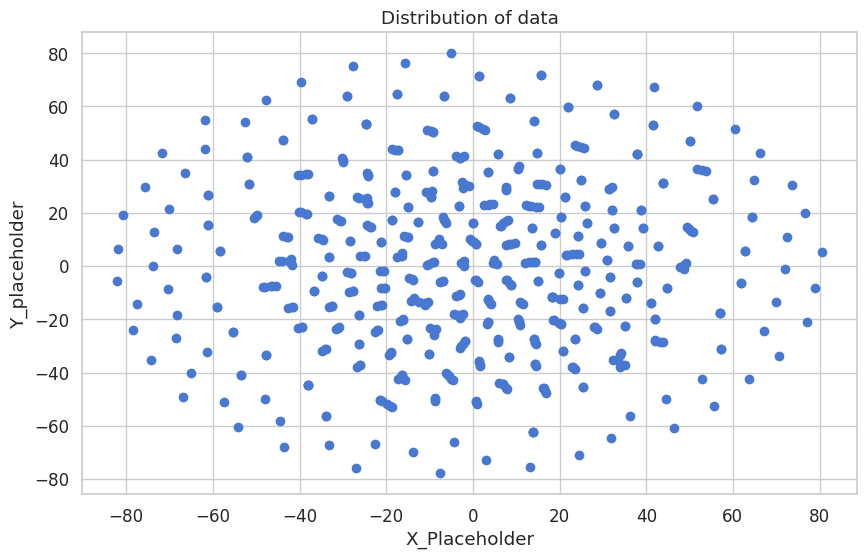

In [ ]:
df_encoded = pd.get_dummies(df[["a_site", "b_site", "spacegroup_symbol",
                   "band_gap", "formation_energy_per_atom", "energy_above_hull"]],
                            drop_first=False)

visualize_data_distribution(df_encoded.to_numpy(), x_feature = "X_Placeholder", y_feature = "Y_placeholder", num_components = 2,
                            perplexity = 1, num_iterations = 500)


#### 2.Bar Plot for Space Group Distribution

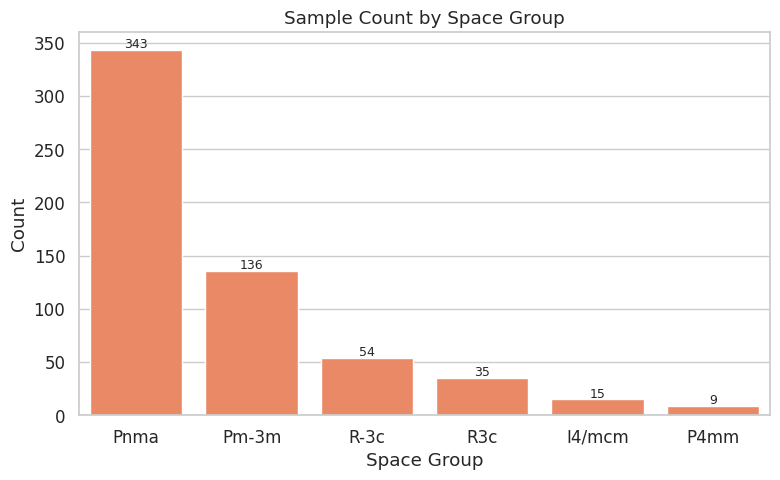

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sg_counts = df['spacegroup_symbol'].value_counts().reset_index()
sg_counts.columns = ['spacegroup_symbol', 'count']

fig, ax = plt.subplots(figsize=(8, 5))

sns.barplot(
    data=sg_counts,
    x='spacegroup_symbol',
    y='count',
    color='coral',
    edgecolor='white',
    ax=ax
)

ax.set_xlabel('Space Group')
ax.set_ylabel('Count')
ax.set_title('Sample Count by Space Group')

# Annotate
for i, row in sg_counts.iterrows():
    ax.text(
        i,
        row['count'] + 2,
        str(row['count']),
        ha='center',
        fontsize=9
    )

plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'fig_spacegroup_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()

#### 3. Violin Plot for Property Distribution

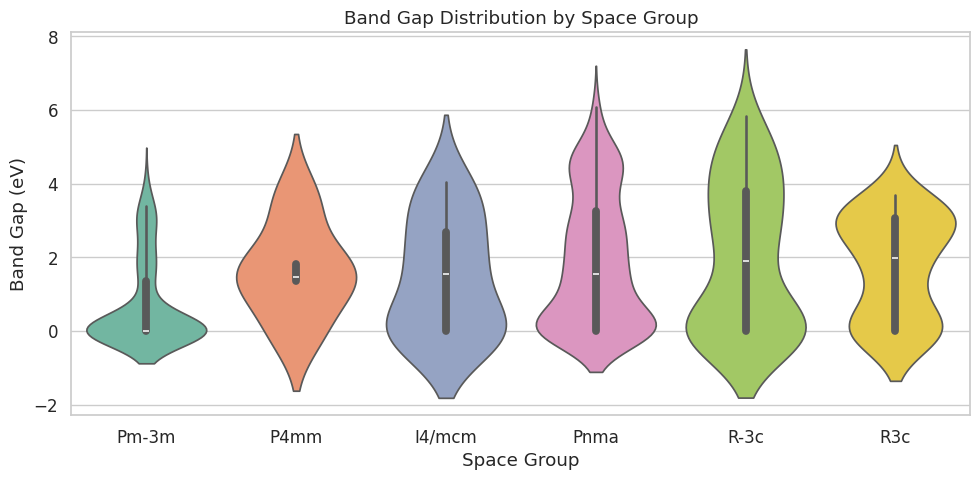

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

order = (
    df.groupby('spacegroup_symbol')['band_gap']
      .median()
      .sort_values()
      .index
)

plt.figure(figsize=(10, 5))
sns.violinplot(
    data=df,
    x='spacegroup_symbol',
    y='band_gap',
    order=order,
    inner='box',
    palette='Set2'
)

plt.xlabel('Space Group')
plt.ylabel('Band Gap (eV)')
plt.title('Band Gap Distribution by Space Group')
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'fig_bandgap_by_sg.png'), dpi=150, bbox_inches='tight')
plt.show()


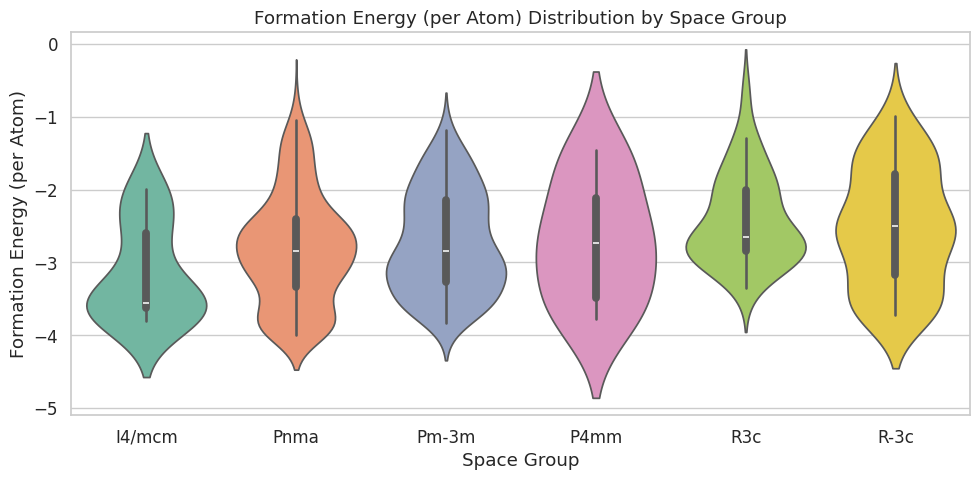

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

order = (
    df.groupby('spacegroup_symbol')['formation_energy_per_atom']
      .median()
      .sort_values()
      .index
)

plt.figure(figsize=(10, 5))
sns.violinplot(
    data=df,
    x='spacegroup_symbol',
    y='formation_energy_per_atom',
    order=order,
    inner='box',
    palette='Set2'
)

plt.xlabel('Space Group')
plt.ylabel('Formation Energy (per Atom)')
plt.title('Formation Energy (per Atom) Distribution by Space Group')
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'fig_formenergy_by_sg.png'), dpi=150, bbox_inches='tight')
plt.show()


#### 4. Scatter Plot for Joint Distribution of Properties

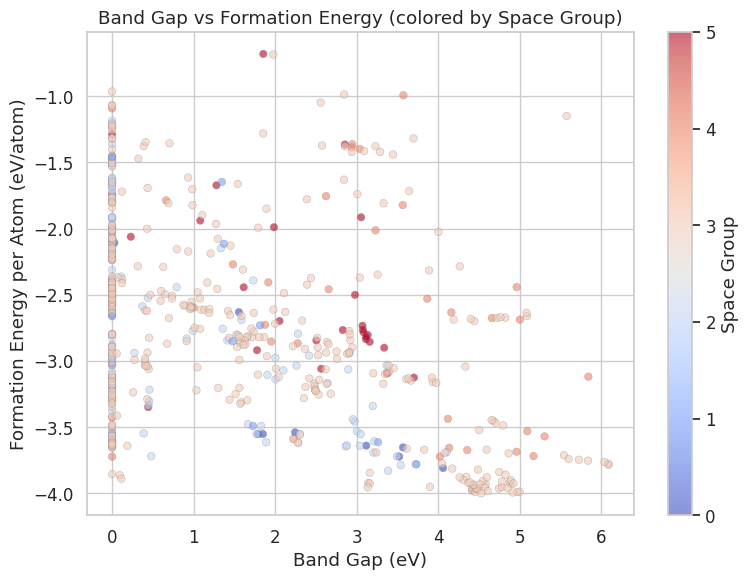

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

sc = plt.scatter(
    df['band_gap'],
    df['formation_energy_per_atom'],
    c=pd.Categorical(df['spacegroup_symbol']).codes,
    cmap='coolwarm',
    alpha=0.6,
    edgecolors='grey',
    linewidth=0.3,
    s=30
)

plt.colorbar(sc, label='Space Group')
plt.xlabel('Band Gap (eV)')
plt.ylabel('Formation Energy per Atom (eV/atom)')
plt.title('Band Gap vs Formation Energy (colored by Space Group)')

plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'fig_bandgap_vs_fe.png'), dpi=150, bbox_inches='tight')
plt.show()


## Part 2: Visualize Samples

The following visualization techniques are applied to randomly selected samples:

- tSNE: include categorical features of the materials (space group, a_site, b_site) as well as numerical target properties (band gap, formation energy, energy above hull), where each of the categorical features is converted into a set of dummy variables

In [22]:
def visualize_samples(data, num_samples = 10):
  """
  Visualizes samples from the dataset.

  Args:
      data (np.array): The dataset that you plan on using as a 2D representation.
      num_samples (int): The number of samples to visualize.
  """

  if num_samples > len(data):
    print(f"Error: Number of samples ({num_samples}) exceeds the dataset size ({len(data)}).")

  # Create np array out of randomly selected samples.
  # Change replace based on if you want to sample with or without replacement
  random_ids = np.random.choice(data.shape[0], size = num_samples, replace = True)
  random_samples = data[random_ids]

  visualize_data_distribution(random_samples, num_iterations = 500)



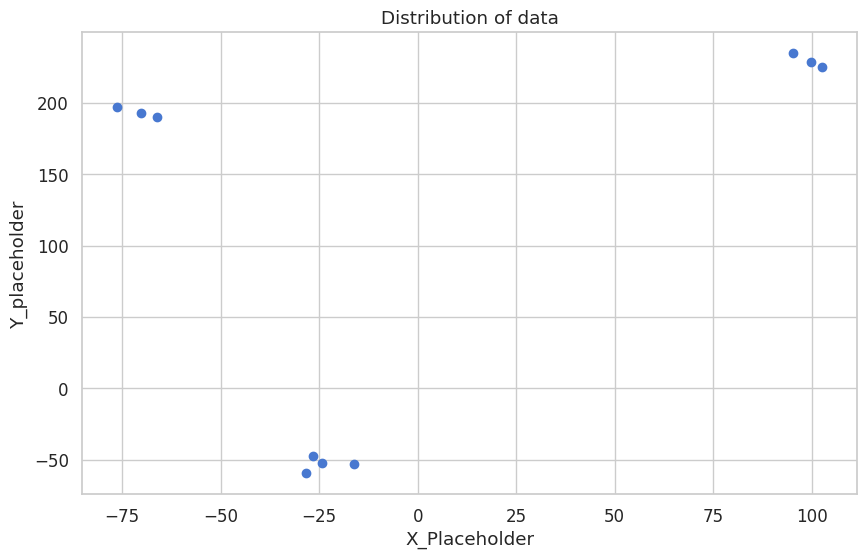

In [23]:
df_encoded = pd.get_dummies(df[["a_site", "b_site", "spacegroup_symbol",
                   "band_gap", "formation_energy_per_atom", "energy_above_hull"]],
                            drop_first=False)

visualize_samples(df_encoded.to_numpy())

## Part 3: Visualize Input Distribution

We use tSNE to visualize different parts of inputs:

- The raw descriptors: the categorical variables

- Text Embeddings: to identify whether the structures from the same space group have similar text embeddings in the latent semantic space

#### 1. Raw Categorical Descriptors

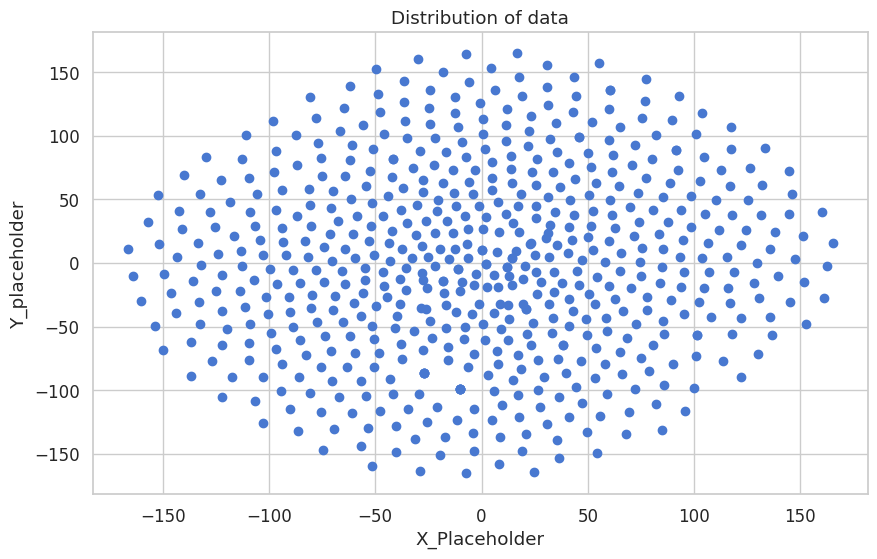

In [24]:
df_encoded = pd.get_dummies(df[["a_site", "b_site", "spacegroup_symbol"]],
                            drop_first=False)

visualize_data_distribution(df_encoded.to_numpy(), x_feature = "X_Placeholder", y_feature = "Y_placeholder", num_components = 2,
                            perplexity = 1, num_iterations = 500)


#### 2. Text Embeddings by Space Group

In [30]:
df_text = df.loc[df['text_ok']].reset_index(drop=True)

texts = []
for f in df_text['text_file']:
    with open(os.path.join(DATA_DIR, f)) as file:
        texts.append(file.read())

print(f'Loaded {len(texts)} text descriptions')

Loaded 493 text descriptions


In [32]:
pip install sentence-transformers

In [33]:
from sentence_transformers import SentenceTransformer
import numpy as np

# Load small free model
model = SentenceTransformer('all-MiniLM-L6-v2')

# texts = [...]  # your list of text strings
X_embed = model.encode(texts, show_progress_bar=True)
print("Embedding matrix shape:", X_embed.shape)


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/16 [00:00<?, ?it/s]

Embedding matrix shape: (493, 384)


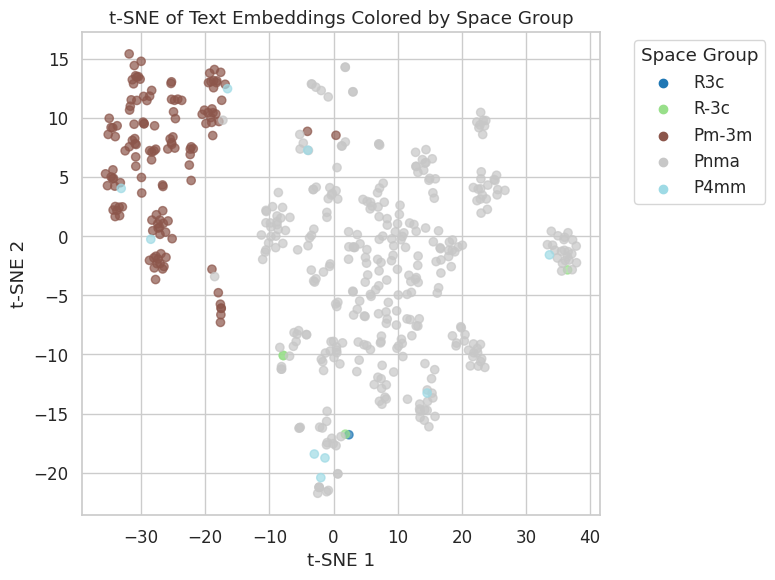

In [36]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Suppose df_text['spacegroup'] contains the space group for each text
space_groups = df_text['spacegroup_symbol']
unique_sg = space_groups.unique()

# Map each unique space group to a color from a colormap
colors = plt.cm.tab20(np.linspace(0, 1, len(unique_sg)))
sg_color_map = dict(zip(unique_sg, colors))

# Create a color array for each point
point_colors = space_groups.map(sg_color_map)



X_pca = PCA(n_components=50, random_state=42).fit_transform(X_embed)
X_tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate='auto',
    init='pca',
    random_state=42
).fit_transform(X_pca)



plt.figure(figsize=(8, 6))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=point_colors, alpha=0.7)

# Add legend
for sg in unique_sg:
    plt.scatter([], [], color=sg_color_map[sg], label=sg)
plt.legend(title='Space Group', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.title('t-SNE of Text Embeddings Colored by Space Group')
plt.tight_layout()
plt.show()


# Section 4:

(20 pts)

Now let's consider what evaluation metrics you would want to use in training and validation. Answer the following:

1. What evalution metrics are you planning on using? Why?
2. Are there any other metrics that could be used here or that you considered?
3. List out the pros and cons of the evaluation metrics you decided to go with.

In addition, code up functions that calculate the metric. We have provided a template to start with. This will be used later for when we do start training models, so take some time in designing this!

## Part 1: What evaluation metrics to use and why

The property prediction tasks are regression tasks, therefore the following metrics are considered suitable for evaluation:

 - **Mean Absolute Error (MAE)**: $MAE = \frac{1}{n}\sum|y_i - \hat{y}_i|$

 <blockquote>

 **Why?** MAE is sutiable for the task because it has the same unit as the target property, and is therefore physically interpretable and easy to compare with the property values. Meanwhile, previous works on AI for materials science have widely used MAE for evaluation (e.g. [leaderboard of the Matbench database](https://matbench.materialsproject.org/)), thus using MAE makes it easier to compare performances with previous models.

 </blockquote>


 - **$R^2$**: $R^2 = 1 - \frac{\sum(y_i-\hat{y}_i)^2}{\sum(y_i-\bar{y})^2}$

 <blockquote>

  **Why?** $R^2$ measures the variance explained with the prediction model, and is therefore ideal for comparing different models. Its scale is strictly between 0 and 1 for any task, making it accessible and understandable across different domains and tasks. The scale also enables us to understand and evaluate performances more easily with just the absolute values of the metric.

 </blockquote>


 - **Root Mean Square Error (RMSE)**: $RMSE = \sqrt{\frac{1}{n}\sum(y_i - \hat{y}_i)^2}$

 <blockquote>

  **Why?** RMSE penalizes large prediction errors more heavily than small ones, making it sensitive to outliers and catastrophic mispredictions. In materials property prediction, large errors can lead to incorrect conclusions about stability or functionality, so emphasizing them is scientifically important. Additionally, RMSE is expressed in the same physical units (eV) as the target, allowing direct interpretability against the true values.

 </blockquote>

## Part 2: Other metrics considerd

The following metrics are also considered but eventually decided to be unsuitable for our tasks:

- **Mean Absolute Percentage Error (MAPE)**
 <blockquote>

  **Issues?** Though MAPE is often used for regression tasks, it's undefined when the true labels (property values) are 0, and are prone to exploding when the true values are small. In the perovskites dataset, some properties like energy above hull are usually close to 0, rendering the metric unstuiable.

 </blockquote>

 - **Mean Sqaured Error (MSE)**
 <blockquote>

  **Issues?** MSE is also a commonly used metric to evaluate regression performances. We plan to use it as the training loss in model implementation, taking advantage of its smoothness and differentiability. When evaluating models and reporting results, we choose to use the closely related RMSE instead, as it has the same unit as the target properties.

 </blockquote>


 - **Accuracy / F1 / AUC**
 <blockquote>

  **Issues?** These are widely used evaluation metrics in materials property prediction, but only for classification tasks. Due to the numerical regression nature of the properties in out dataset, these metrics are not used.

 </blockquote>

## Part 3: Pros and cons of metrics to use

- **Mean Absolute Error (MAE)**: $MAE = \frac{1}{n}\sum|y_i - \hat{y}_i|$

 <blockquote>

**Pros**: MAE has the same unit as the target property, therefore is physically interpretable and comparable. It's robust to outliers, and has been widely reported in previous works and leaderboards.

**Cons**: MAE doesn't significantly penalize large errors, and is not differentiable at 0.

 </blockquote>


 - **$R^2$**: $R^2 = 1 - \frac{\sum(y_i-\hat{y}_i)^2}{\sum(y_i-\bar{y})^2}$

 <blockquote>

**Pros**: $R^2$ measures variance explained by the models, and is unitless and useful for model comparison. Its fixed scale makes it easy to understand and evaluate.

**Cons**: $R^2$ is not physically meaningful or interpretable, and can be misleadingly high even when absolute errors are large.

 </blockquote>


 - **Root Mean Square Error (RMSE)**: $RMSE = \sqrt{\frac{1}{n}\sum(y_i - \hat{y}_i)^2}$

 <blockquote>

**Pros**: RMSE penalizes large errors more heavily, and is expressed in original unit.

**Cons**: RMSE is sensitive to outliers and can be skewed with a few large errors.

 </blockquote>

## Part 4: Code up the functions

In [1]:
import numpy as np

def mae(y_true, y_pred):
    """
    Mean Absolute Error
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return np.mean(np.abs(y_true - y_pred))


def r2_score(y_true, y_pred):
    """
    Coefficient of Determination (R^2)
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)

    if ss_tot == 0:
        return 0.0  # avoids division by zero

    return 1 - ss_res / ss_tot


def rmse(y_true, y_pred):
    """
    Root Mean Squared Error
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return np.sqrt(np.mean((y_true - y_pred) ** 2))


# Section 5:

(15 pts)

For the next part of this assignment, we are going to play around with instruction tuning. This is when you prompt the model in specifc ways to guarentee a specific output. Provide prompts that would be able to guarentee the right output based on the data.

Scenario 1: You have a dataset of reviews from restaurants, when you see this review:
"This place stinks, the service was awful and the food was not cooked. I will never come back here!"
Provide a prompt that would have the model return the sentiment of the review, which is negative.

Scenario 2: You are looking through a dataset of angry, sad, and happy faces. Provide a prompt that would get the emotion a person is expressing.

Scenario 3: A dataset of novels, with the following paragraph:
"The man, Edgar, flew to Italy to hike the Alps. He was looking forward to going skiing there."

Provide prompts to get the name of the subject, where they are going, and what they were planning to do.

## Scenario 1:

You have a dataset of reviews from restaurants, when you see this review: "This place stinks, the service was awful and the food was not cooked. I will never come back here!" Provide a prompt that would have the model return the sentiment of the review, which is negative.

**Prompt**:

You are a sentiment analysis assistant.

Read the following restaurant review and determine the overall sentiment. Only respond with one word: 'positive', 'neutral', or 'negative'. Don't provide any other information or explanations.

The review is: [REVIEW]

## Scenario 2

You are looking through a dataset of angry, sad, and happy faces. Provide a prompt that would get the emotion a person is expressing.

You are an emotion recognition assistant.

Look at the image of a face and determine the emotion the person is expressing. Only respond with one word: 'angry', 'sad', or 'happy'. Don't provide anything else.

The image of the face is: [IMAGE]

## Scenario 3

A dataset of novels, with the following paragraph: "The man, Edgar, flew to Italy to hike the Alps. He was looking forward to going skiing there."

Provide prompts to get the name of the subject, where they are going, and what they were planning to do.

You are a named entity extraction assistant.

Read the paragraph and extract the following information. Respond only in JSON format with keys 'name', 'destination', and 'planned_activity'.

The paragraph is here: [PARAGRAPH]

# Section 6 (Bonus)

**As a bonus part of this assignment (10 points of extra credit)**, we welcome you to do the following: Create a project where you create a dataset (separate from the one you will be using for the rest of the HWs) and train some models on the dataset. For the bonus credit, explain what goal you went with, the model you decided to use, and the evalutaion metrics used. Explain your reasoning for each of the choices. Be as creative as possible!

Here is what we are looking for:
* What is the task you are looking to do
* What dataset you are using
* The modalities you will extract
* What model you will be using
* The evaluation metrics you employ
* Results from training adn testing using the evaluation metrics

Be sure to provide a rationale for each design choice!



In [ ]:
# BONUS CODE HERE


# Section 7

(5 pts)

Now, let's take some time to reflect. We have dug deep into the data collection and process portion of machine learning. Take some time to discuss:

1. The most interesting topic discussed in this homework assignment.
2. A challenging aspect that you did not expect to deal with and what insights you used to address it.
3. How you feel about the overall quality of your dataset? Is there anything lacking? What is particularly great about it?

There is no specific right answer we are looking for, answer how you think!

### 1. Most interesting topic

The instruction tuning part feels the most interesting to me personally. As a standalone section in the assignment, it helps me to both think about the applied scenarios beyond my own dataset and tasks, and explore ways to guide model behaviors through careful but simple designs

### 2. Unexpected challenging aspect

One particular challenging part of the assignment was to acquire the raw data files for material structures of interest. It was also an unexpected challenge as I have mostly been using already-curated datasets for most of my previous projects. The necessity to carefully design steps to filter down the database and check for consistency was a challenging experience but also reminds me of the essence of making efforts to guarantee high-quality data curation.

### 3. Overall quality of dataset

The dataset was guaranteed to be relevant to the proposed tasks and to contain only reasonably simulated materials. Both structure files and text descriptions have been paired, and th target properties are well recorded for each data instance. For the purpose of exploring multimodal AI methods with matched inputs and outputs, the dataset is ready to go. It is particularly great due to the rigorous screening based on domain expertise, ensuring the daatset is clean and relevant for perovskite applications. However, the lacking of successfully generated text for a small portion of the sample remains a challenge to address. Meanwhile, the limited dataset size and the limitation of the data for exploring generative and agentic tasks may still require further efforts in future assignments and the project to tackle.